# Processing of RO-Crate for publishing
This notebook will read and RO-Crate file from galaxy, extract the provenance information as PROV-O in JSON-LD and save it into a new version of the RO-Crate.

1. read galaxy ro-crate
2. read the workflow file to get the prospective provenance
3. read the workflow run to get the retrospective provenance
4. merge the provenances into a PROV-O graph
5. save the PROV-O graph in the RO-Crate
6. get a publishable package consisting of RO-Crate + context (a JSON-LD file). The context metadata as JSON-LD is intended to facilitate discovery and interoperability
7. publish package to Invenio RDM (Zenodo if possible)


In [1]:
import zipfile
from pathlib import Path
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, RDFS, XSD, DCTERMS
import json


# library to support visualisation of graphs
from rdflib.extras.external_graph_libs import rdflib_to_networkx_graph

# pyvis used to display the graphs
from pyvis.network import Network


# Namespaces
PROV = Namespace("http://www.w3.org/ns/prov#")
SCHEMA = Namespace("http://schema.org/")
SKOS = Namespace("http://www.w3.org/2004/02/skos/core#")
PPLAN = Namespace("https://vocab.linkeddata.es/p-plan#")

file_formats = {"txt":"text/plain", "cif": "chemical/x-cif",
                "png":"image/png", "prj": "application/vnd.demeter.athena",
                "sp":"text/csv", "gds":"text/csv", "feffit":"text/plain", 
                "feff":"text/csv", "zip":"application/zip",
                "inp":"chemical/x-feff-input",
                "tabular": "text/plain",
                "h5": "application/x-hdf5",
                "jsonld": "application/ld+json"
               }

# read file from zipped RO-Crate file
def get_file_from_rocratezip(zip_file, file_name):
    roc_zip_file = zipfile.ZipFile(zip_file)
    return roc_zip_file.open(file_name)
    
# Read the zipped crate and get main metadata file
def load_rocrate_metadata(crate_file):
    roc_zip_file = zipfile.ZipFile(crate_file)
    f = get_file_from_rocratezip(crate_file, "ro-crate-metadata.json")
    crate = json.load(f)
    return crate["@graph"]

#Return all JSON-LD entities of a given @type.
def find_entities(graph, type_name):
    return [e for e in graph if type_name in e.get("@type", [])]

#Convert RO-Crate IDs to URIs.
def to_uri(crate_base, entity_id):
    return URIRef(crate_base + entity_id)

#Convert json-ld crate to turtle
def crate_to_turtle(crate_path, save_path):
    g = Graph()
    roc_zip_file = zipfile.ZipFile(crate_path)
    f = roc_zip_file.open("ro-crate-metadata.json")
    g.parse(f,format="json-ld")
    out_ttl = Path(save_path, "ro-crate-metadata.ttl")
    print(f"saving to {out_ttl}")
    g.serialize(destination=out_ttl, format="turtle")

# get galaxy workflow file from RO-Crate
def get_workflow_json(ro_crate_zip):
    graph = load_rocrate_metadata(ro_crate_zip)
    roc_files = find_entities(graph, "File")
    workflow_file = ""
    for a in roc_files:
        if a['@id'][-3:] == ".ga" :
            workflow_file = a['@id']
            break    
    f = get_file_from_rocratezip(ro_crate_zip, workflow_file)
    wf_ga_json = json.load(f)
    return wf_ga_json

# get txt containing entities RO-Crate metadata:
# invocation, datasets, etc
def get_roc_json_part(ro_crate_zip, file_name):
    graph = load_rocrate_metadata(ro_crate_zip)
    roc_file = ""
    roc_all_files = find_entities(graph, "File")
    for a in roc_all_files:
        if file_name in a['@id']:
            roc_file = a['@id']
            break
    f = get_file_from_rocratezip(ro_crate_zip, roc_file) 
    file_json = json.load(f)
    return file_json

# data sets are mapped to history objects
def get_history_mapped_ds(datasets_json, history_mapping):
    ds_id = ""
    for ds in datasets_json:
        chain = ds.get("copied_from_history_dataset_association_id_chain", [])
        if history_mapping in chain or history_mapping == ds["encoded_id"]:
            ds_id = ds["encoded_id"]
    return ds_id

# link ds generator to corresponding wf step
def get_wf_step(ds_uri, a_graph):
    
    ds_label =  get_a_label(a_graph, ds_uri)
    ret_val = None
    # fetch steps have the ds_name as the label
    for an_activity, p, o in a_graph.triples((None, RDFS.label, Literal(ds_label))):
        ret_val = an_activity                
    return ret_val

# get label associated to a subject
def get_a_label(graph_thing, a_subject):
    # Try SKOS prefLabel
    for a_label in graph_thing.objects(a_subject, SKOS.prefLabel):
        return str(a_label)

    # Try RDFS label
    for a_label in graph_thing.objects(a_subject, RDFS.label):
        return str(a_label)

    return ""

# lookup the collections table to find the jobs associated to steps
def find_jobs_by_hda_id(invoked_jobs, data_collections, hda_list):
    jobs_for_step = []
    # Build lookup maps 
    # lookup map for jobs by hda_id
    jobs_by_output_hda = {
          list(job['output_dataset_mapping'].values())[0][0]: job for job in invoked_jobs
        }
    # lookup map for collections by collection id
    collections_by_id = {c['encoded_id']: c for c in data_collections}
    
    for hda_id in hda_list:
        collection = collections_by_id.get(hda_id)
        if not collection:
            continue
    
        for element in collection['collection']['elements']:
            element_hda_id = element['hda']['encoded_id']
    
            job = jobs_by_output_hda.get(element_hda_id)
            if job:
                #print(f"Found job {job['encoded_id']} for HDA {element_hda_id}")
                jobs_for_step.append(job['encoded_id'])
    #print (f"step id: {step_id}, jobs: {jobs_for_step}")
    return jobs_for_step

# add custom labels to activities
def custom_labels(a_graph):
    for an_activity in a_graph.subjects(RDF.type, PROV.Activity):
        #print(f"Activity {an_activity}")
        for an_agent in a_graph.objects(an_activity, PROV.wasAssociatedWith):
            #print(f"Activity {an_activity} associated with {an_agent}")
            for agent_label in a_graph.objects(an_agent, RDFS.label):
                #print(f"Agent label: {agent_label}")
                d_label = str(agent_label)
                pref_label = ""
                if d_label == "larch_athena":
                    pref_label = "process and normalise XAS"
                elif d_label == "larch_artemis":
                    pref_label = "FEFF fit of XAS"
                elif d_label == "larch_select_paths":
                    pref_label = "select FEFF paths"
                elif d_label == "larch_feff":
                    pref_label = "calculate FEFF paths from crystal"
                elif d_label == "larch_lcf":
                    pref_label = "linear combination fit of XAS"
                elif d_label == "larch_plot":
                    pref_label = "plot XAS data"
                elif d_label == "larch_criteria_report":
                    pref_label = "report on FEFF fitting"
                elif d_label == "DATA_FETCH":
                    pref_label = "fetch data from history"
                elif d_label == "EXTRACT_DATASET":
                    pref_label = "extract dataset from collection"                    
            if pref_label != "":
                a_graph.add((an_activity, SKOS.prefLabel, Literal(pref_label)))

    
# extract steps from wf and invocation files to create prov plan
# extract steps from wf and invocation files to create prov plan
def roc_provo(crate_path, out_path, output_file="galaxy_run_prov.ttl"):
    workflow_file = ""
    invocation_file = "" 

    # Load workflow (prospective provenance)
    wf = get_workflow_json(crate_path)
    steps = wf.get("steps", {})

    # Load invocation (retrospective provenance)
    inv = get_roc_json_part(crate_path,"invocation_attrs.txt")
    inv_steps = inv[0].get("steps", {})

    # load implicit job collections ()
    # these are parallelised executions from a single step in the workflow
    implicit_job_links = get_roc_json_part(crate_path, "implicit_collection_jobs_attrs.txt")
    
    # Load dataset attributes (encoding, names, ) 
    # to gather dataset attributes
    ds_attributes = get_roc_json_part(crate_path,"datasets_attrs.txt")

    # load ds collections
    # these collections map to grouped inputs (using lists) which are unpacked by fetch data
    ds_collections = get_roc_json_part(file_path, "collections_attrs.txt")

    # Load job attributes
    # gather input links
    invoked_jobs = get_roc_json_part(crate_path,"jobs_attrs.txt")
    
    g = Graph()

    # define namespaces in graph
    for p, ns in [("prov", PROV), ("schema", SCHEMA), ("skos", SKOS), ("p-plan", PPLAN)]:
        g.bind(p, ns)

    base = "/"

    # --- 1. Workflow definition as prov:Plan ---
    wf_uri = URIRef(base + "workflow")
    g.add((wf_uri, RDF.type, PPLAN.Plan))
    g.add((wf_uri, RDFS.label, Literal(wf.get("name", "Galaxy Workflow"))))

    # --- 2. Prospective provenance: workflow steps ---
    for step_id, step in steps.items():
        step_uri = URIRef(base + f"step/{step_id}")
        g.add((step_uri, RDF.type, PPLAN.Step))
        step_label = step.get("label") or step.get("tool_id")
        g.add((step_uri, RDFS.label, Literal(step_label)))

        # Link step to workflow plan
        g.add(( step_uri, PPLAN.isStepOfPlan, wf_uri))

        # Prospective inputs
        for inp in step.get("input_connections", {}).values():
            if isinstance(inp, dict) and "id" in inp:
                src = URIRef(base + f"step/{inp['id']}")
                g.add((step_uri, PPLAN.isPrecededBy, src))
    
    # --- 3. Retrospective provenance: actual execution --- 
    # invocations are only used to link actities to wf steps
    for inv_step in inv_steps:   
        
        job = inv_step.get("job")
        job_collection_prop = inv_step.get("implicit_collection_jobs")
        job_ids = []
        
        if job: 
            job_ids = [job['encoded_id']]
        elif job_collection_prop:
            job_collection_id = job_collection_prop.get("encoded_id") 
            for a_job_collection in implicit_job_links:
                if a_job_collection['encoded_id'] == job_collection_id:
                    job_ids = a_job_collection['jobs']
        else: 
            cid_list = []
            for out in inv_step.get("output_collections", []):
                cid_list.append(out['dataset_collection']['encoded_id'])
            
            job_ids = find_jobs_by_hda_id(invoked_jobs, ds_collections, cid_list)
            if cid_list == []:
                continue

        step_index = f"{inv_step['order_index']}"
        step_uri = URIRef(base + f"step/{step_index}")
        for a_job_id in job_ids:
            act_uri = URIRef(base + f"run/{a_job_id}")   
            g.add((act_uri, PPLAN.correspondsToStep, step_uri))

    # Add datset attributes
    for a_ds in ds_attributes:
        ent_uri = (URIRef(base + f"dataset/{a_ds['encoded_id']}"))
        format_str =  file_formats[a_ds['extension']]

        g.add((ent_uri, RDF.type, PROV.Entity)) # duplicated only used for WF_inputs which are not in invocation
        g.add((ent_uri, DCTERMS.format, Literal(format_str)))
        g.add((ent_uri, DCTERMS.description, Literal(a_ds['info'])))
        g.add((ent_uri, SCHEMA.name, Literal(a_ds['file_name'])))
        g.add((ent_uri, SKOS.prefLabel, Literal(a_ds['name']) ))

    # Add the missing links to inputs
    for a_job in invoked_jobs:
        job_uri = URIRef(base + f"run/{a_job['encoded_id']}")
        # link all used datasets to activites
        for a_mapping in a_job['input_dataset_mapping']:
            for a_ds_id in  a_job['input_dataset_mapping'][a_mapping]:
                ds_uri = URIRef(base + f"dataset/{a_ds_id}")
                g.add((job_uri, PROV.used, ds_uri))
                
    for a_job in invoked_jobs:
        job_uri = URIRef(base + f"run/{a_job['encoded_id']}")
        tool_label = a_job['tool_id'].lstrip("_").rstrip("_")
        tool_uri = URIRef(f"/srv/galaxy/var/shed_tools/{a_job['tool_id']}")# causing problems
        tool_version = a_job['tool_version']
        if "toolshed" in a_job['tool_id']:
            tool_label, tool_version  =   a_job['tool_id'].split("/")[-2:]
        elif a_job['command_line']:
             tool_uri = URIRef(str(a_job['command_line'].split(' ')[1].strip("'")))
        else:
            tool_uri = URIRef(base + f"galaxy_tool/{tool_label.lower()}")

        g.add((tool_uri, RDF.type, PROV.SoftwareAgent))
        g.add((tool_uri, RDFS.label, Literal(tool_label)))
        g.add((tool_uri, SCHEMA.softwareVersion, Literal(tool_version)))
        # This should only add labes for datafetch activites which are not invocations
        g.add((job_uri, RDF.type, PROV.Activity))
        g.add((job_uri, RDFS.label, Literal(tool_label)))
        g.add((job_uri, PROV.wasAssociatedWith, tool_uri))

        # link output_dataset_mappings
        for a_mapping in a_job['output_dataset_mapping']:
            for a_mapping_id in  a_job['output_dataset_mapping'][a_mapping]:
                a_ds_id = get_history_mapped_ds(ds_attributes, a_mapping_id)
                ds_uri = URIRef(base + f"dataset/{a_ds_id}")
                g.add((ds_uri, PROV.wasGeneratedBy, job_uri)) #already done for most only pending for data fetch
                g.add((ds_uri, PROV.wasAttributedTo, tool_uri))
                
                # these are also for data fetch only
                # link to associated plan activity
                step_uri = get_wf_step(ds_uri, g)
                if step_uri != None:
                    g.add((job_uri, PPLAN.correspondsToStep, step_uri))
        
        for a_mapping in a_job['input_dataset_mapping']:
            for a_ds_id in  a_job['input_dataset_mapping'][a_mapping]:
                ds_uri = URIRef(base + f"dataset/{a_ds_id}")
                g.add((ds_uri, PROV.wasAttributedTo, tool_uri))

    # Assing human readable labels to activities
    custom_labels(g)
    
    # --- Save ---
    save_ttl = Path(out_path, output_file)
    g.serialize(destination=save_ttl, format="turtle")
    
    graph_context={
            "@vocab": str(PROV),
            "prov": str(PROV),
            "p-plan": str(PPLAN),
            "schema": str(SCHEMA),
            "skos": str(SKOS),
            "rdfs": str(RDFS),
            "dcterms": str(DCTERMS),
        }
    save_json = Path(out_path, output_file[:-4]+".json")
    g.serialize(destination=save_json, format="json-ld", 
                context=graph_context, auto_compact=True, indent=2)
    return g        

# Inputs

These are the RO-Crates used for testing

In [2]:
input_folder = "./input"
# "FeS2-Analysis.rocrate.zip" # OK 
# "FeS2-Analysis-Mod_01.rocrate.zip" # OK  
# "Paper_1_Pt3Sn.rocrate.zip" # fail to link some activities to pplan step 1 (99)
# "Paper_2_Diphosphine.rocrate.zip" # OK
# "Paper_3-Au-colloids202604.rocrate.zip" # OK Corrected ROC, fail was because of unasigned inputs
# "paper_4_Palladium-CO.rocrate.zip" # OK
# "Paper_5-LaMnO3-Catalytic-Behaviour.rocrate.zip" # OK 
# "Paper_6_100C_175C_300C.rocrate.zip" # OK
# "Paper_6-PdAl2O3_100C_175C_300C.rocrate.zip" # OK
# "Paper_7-MoOxAl2O3.rocrate.zip" # OK 
# "Paper_8-EXAFS-fitting.rocrate.zip" # fail to link activities to pplan step and activities to DS 2 (209)
# "Paper_9-N2O-LaMnO3-Figs1.rocrate.zip" # OK
# "Paper_9-N2O-LaMnO3-Figs6202604.rocrate.zip" # OK Corrected ROC and added SwAgent extract dataset
# "Invocation-of-CDIF-Test-2026-04-22.rocrate.zip" # First CDIF testing RO Crate
file_name = "FeS2-Analysis.rocrate.zip"

output_folder = "./output"
working_folder = file_name[:-4]

file_path = Path(input_folder,file_name)

output_path = Path(output_folder,working_folder)

if output_path.exists():
    print(f"saving output to existing folder: {output_path}")
else :
    Path(output_path).mkdir(parents=True, exist_ok=True)
    print(f"created folder for saving output: {output_path}")

if file_path.exists():
    print(f"Working with {str(file_path)}")
    roc_zip_file = zipfile.ZipFile(file_path)

    ro_crate_contents = roc_zip_file.namelist()

    f = roc_zip_file.open("ro-crate-metadata.json")
    content = f.read()

crate_to_turtle(file_path, output_path)

roc_graph = roc_provo(file_path, output_path)

saving output to existing folder: output\FeS2-Analysis.rocrate
Working with input\FeS2-Analysis.rocrate.zip
saving to output\FeS2-Analysis.rocrate\ro-crate-metadata.ttl


# Network Graph
Draw the network graph with all the triples

In [3]:
nx_graph = rdflib_to_networkx_graph(roc_graph) #load graph
print(f"Newtworkx {nx_graph} loaded successfully")

nt = Network("800px", "100%", notebook="True")
nt.from_nx(nx_graph)
nt.show_buttons(filter_=["physics"])
nt.show("nx.html")

Newtworkx Graph with 91 nodes and 171 edges loaded successfully
nx.html


# Display PROV-O graph 
We wan to display the graph using the notation from the W3C document ([PROV-O](https://www.w3.org/TR/prov-o/)). 

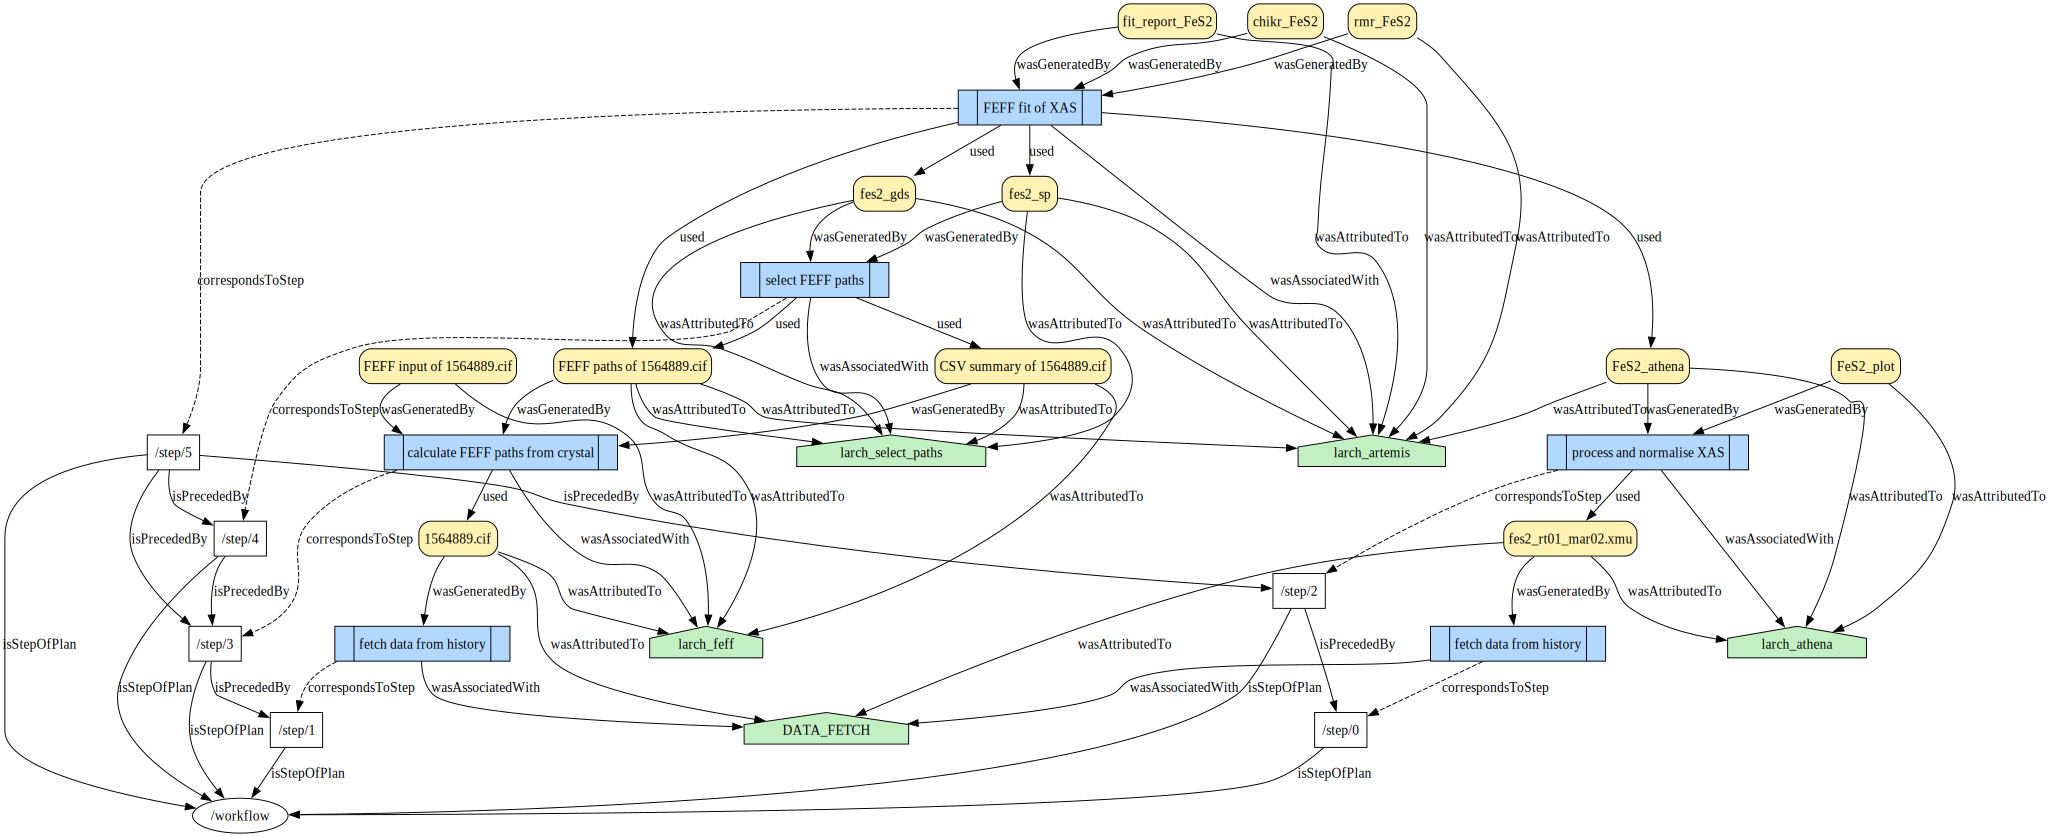

In [4]:
from rdflib import Graph, Namespace, RDF
from graphviz import Digraph
from IPython.display import display

import os

# this path is needed for grapviz to work on win
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin/'

def draw_pplan_only(a_graph):
    dot = Digraph("prov")
    for s, p, o in a_graph:
        node_str = get_a_label(a_graph, s)
        if (s, RDF.type, PPLAN.Step) in a_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label=node_str, shape="box")
        elif (s, RDF.type, PROV.Activity) in a_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label = f"<f0>|<f1>{node_str}|<f2> ", shape="record", style="filled", fillcolor="#b2d8ff")
        if p.startswith(PPLAN):
            if "correspondsTo" in str(p):
                dot.edge(str(s), str(o), label=p.split("#")[-1], style="dashed")
            else:
                dot.edge(str(s), str(o), label=p.split("#")[-1])
    return dot

def draw_prov_only(a_graph):
    dot = Digraph("prov")

    for s, p, o in a_graph:
        # classify nodes
        node_str = get_a_label(a_graph, s)
        if node_str == "":
            node_str = str(s) 
        if (s, RDF.type, PROV.Entity) in a_graph:
            dot.node(s, label=node_str, shape="box", style="rounded, filled", fillcolor="#fff2b2")
        elif (s, RDF.type, PROV.Activity) in a_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label = f"<f0> |<f1>{node_str}|<f2> ", shape="record", style="filled", fillcolor="#b2d8ff")
        elif (s, RDF.type, PROV.SoftwareAgent) in a_graph:
            dot.node(s, label=node_str, shape="house", style="filled", fillcolor="#c2f0c2")            
    
        # add edges with labels
        if p.startswith(PROV):
            dot.edge(str(s), str(o), label=p.split("#")[-1])
    return dot

def draw_prov_full(a_graph):
    dot = Digraph("prov")

    for s, p, o in a_graph:
         # classify nodes
        node_str = get_a_label(a_graph, s)
        if node_str == "":
            node_str = str(s) 
        if (s, RDF.type, PROV.Entity) in a_graph:
            dot.node(s, label=node_str, shape="box", style="rounded, filled", fillcolor="#fff2b2")
        elif (s, RDF.type, PROV.Activity) in a_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label = f"<f0>|<f1>{node_str}|<f2> ", shape="record", style="filled", fillcolor="#b2d8ff")
        elif (s, RDF.type, PROV.SoftwareAgent) in a_graph:
            dot.node(s, label=node_str, shape="house", style="filled", fillcolor="#c2f0c2")
        elif (s, RDF.type, PPLAN.Step) in a_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label=node_str, shape="box")
            
    
        # add edges with labels
        if p.startswith(PROV):
            dot.edge(str(s), str(o), label=p.split("#")[-1])
        elif p.startswith(PPLAN):
            if "correspondsTo" in str(p):
                dot.edge(str(s), str(o), label=p.split("#")[-1], style="dashed")
            else:
                dot.edge(str(s), str(o), label=p.split("#")[-1])
    return dot

graph_file = Path(output_path, "prov_full") 
dot_prov_full = draw_prov_full(roc_graph)
dot_prov_full.render(graph_file, format="png")
display(dot_prov_full)

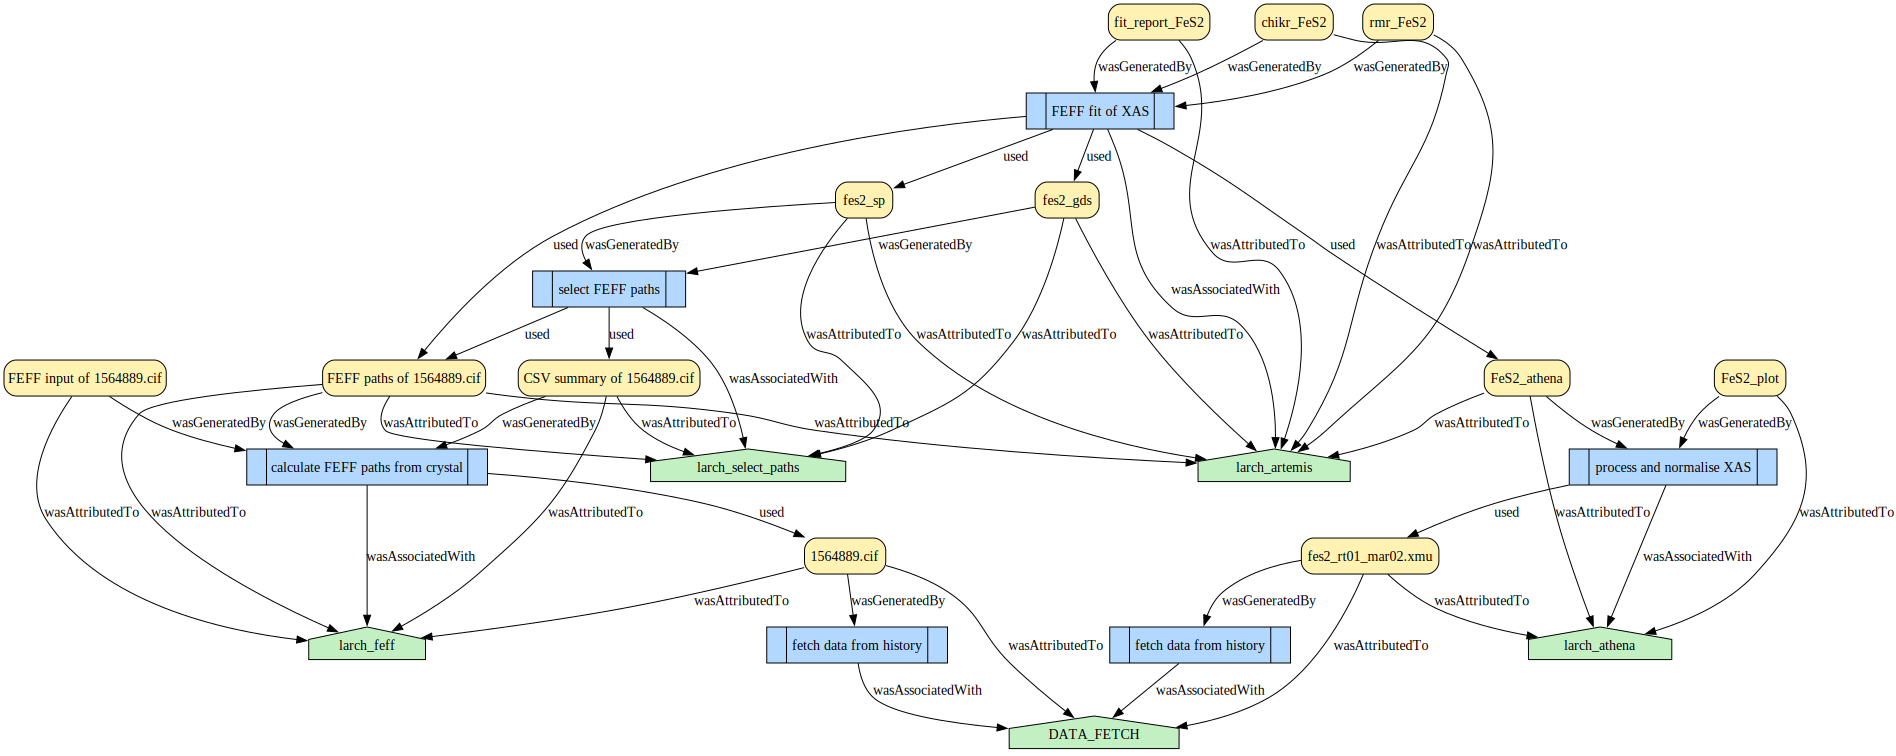

In [5]:
graph_file = Path(output_path, "prov_only") 
prov_dot = draw_prov_only(roc_graph)
prov_dot.render(graph_file, format="png")
display(prov_dot)

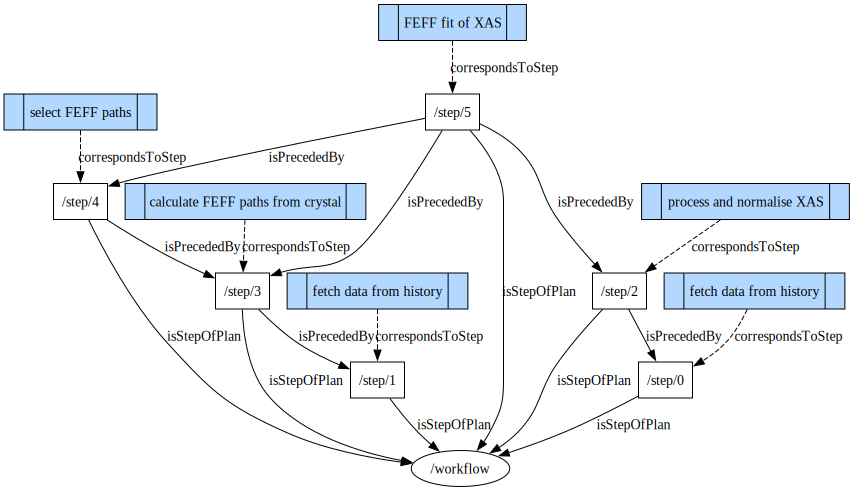

In [6]:
graph_file = Path(output_path, "pplan_only") 

plan_dot = draw_pplan_only(roc_graph)
plan_dot.render(graph_file, format="png")
display(plan_dot)

# Present provenance in table
We need to build a table from the RDF graph. The table shows the activity, the agent, the resulting dataset and the inputs that helped creating it.

activity -> agent/tool -> Entity (dataset) -> inputs 


In [7]:
# put provenance in a table structure
import pandas as pd
# present data as html table
from IPython.display import display, HTML

qres = roc_graph.query("""
PREFIX prov:   <http://www.w3.org/ns/prov#>
PREFIX skos:   <http://www.w3.org/2004/02/skos/core#>
PREFIX rdfs:  <http://www.w3.org/2000/01/rdf-schema#>
PREFIX schema:<https://schema.org/>
PREFIX pplan: <https://vocab.linkeddata.es/p-plan#>

SELECT
  ?step
  ?dataset
  ?activityLabel
  ?tools
  ?inputs
WHERE {
  # --------------------------------------------------
  # core relation
  # --------------------------------------------------
  ?output prov:wasGeneratedBy ?activity .

  # --------------------------------------------------
  # output (dataset) label — ONE label per output
  # --------------------------------------------------
  OPTIONAL {
    SELECT ?output
           (COALESCE(MAX(?pref), MAX(?name), MAX(?label), STR(?output)) AS ?dataset)
    WHERE {
      OPTIONAL { ?output skos:prefLabel ?pref }
      OPTIONAL { ?output schema:name    ?name }
      OPTIONAL { ?output rdfs:label     ?label }
    }
    GROUP BY ?output
  } 

  # --------------------------------------------------
  # wf step — related to activity
  # --------------------------------------------------
  OPTIONAL {
    SELECT ?activity
           ?step
    WHERE {
      ?activity pplan:correspondsToStep ?step .
    }
  }

  # --------------------------------------------------
  # activity label — ONE label per activity
  # --------------------------------------------------
  OPTIONAL {
    SELECT ?activity
           (COALESCE(MAX(?pref), MAX(?name), MAX(?label), STR(?activity)) AS ?activityLabel)
    WHERE {
      OPTIONAL { ?activity skos:prefLabel ?pref }
      OPTIONAL { ?activity schema:name    ?name }
      OPTIONAL { ?activity rdfs:label     ?label }
    }
    GROUP BY ?activity
  }

  # --------------------------------------------------
  # tools / agents — MANY tools aggregated per activity
  # --------------------------------------------------
  OPTIONAL {
    SELECT ?activity
           (GROUP_CONCAT(DISTINCT COALESCE(?pref, ?name, ?label, STR(?tool)); separator=", ") AS ?tools)
    WHERE {
      ?activity prov:wasAssociatedWith ?tool .
      OPTIONAL { ?tool skos:prefLabel ?pref }
      OPTIONAL { ?tool schema:name    ?name }
      OPTIONAL { ?tool rdfs:label     ?label }
    }
    GROUP BY ?activity
  }

  # --------------------------------------------------
  # inputs — MANY inputs aggregated per activity
  # --------------------------------------------------
  OPTIONAL {
    SELECT ?activity
           (GROUP_CONCAT(DISTINCT COALESCE(?pref, ?name, ?label, STR(?input)); separator=", ") AS ?inputs)
    WHERE {
      ?activity prov:used ?input .
      OPTIONAL { ?input skos:prefLabel ?pref }
      OPTIONAL { ?input schema:name    ?name }
      OPTIONAL { ?input rdfs:label     ?label }
    }
    GROUP BY ?activity
  }
}
ORDER BY ?step
""")

df = pd.DataFrame(
    [(str(s), str(a), str(t), str(o), str(i)) for s, o, a, t, i in qres],
    columns=["Step", "Activity", "Tool", "Dataset", "Inputs"]
)

In [8]:
display(HTML(df.to_html().replace("\\n","<br>")))

,Step,Activity,Tool,Dataset,Inputs
0,/step/0,fetch data from history,DATA_FETCH,fes2_rt01_mar02.xmu,None
1,/step/1,fetch data from history,DATA_FETCH,1564889.cif,None
2,/step/2,process and normalise XAS,larch_athena,FeS2_athena,fes2_rt01_mar02.xmu
3,/step/2,process and normalise XAS,larch_athena,FeS2_plot,fes2_rt01_mar02.xmu
4,/step/3,calculate FEFF paths from crystal,larch_feff,FEFF input of 1564889.cif,1564889.cif
5,/step/3,calculate FEFF paths from crystal,larch_feff,CSV summary of 1564889.cif,1564889.cif
6,/step/3,calculate FEFF paths from crystal,larch_feff,FEFF paths of 1564889.cif,1564889.cif
7,/step/4,select FEFF paths,larch_select_paths,fes2_gds,"CSV summary of 1564889.cif, FEFF paths of 1564889.cif"
8,/step/4,select FEFF paths,larch_select_paths,fes2_sp,"CSV summary of 1564889.cif, FEFF paths of 1564889.cif"
9,/step/5,FEFF fit of XAS,larch_artemis,chikr_FeS2,"FeS2_athena, FEFF paths of 1564889.cif, fes2_gds, fes2_sp"


# Datasets in Detail
Using the PROV-O file, we can get the details of each dataset and display them in a user friendly way


In [9]:
# get a dict of dataset details
def get_dataset_properties(a_dataset, a_graph):
    ds_data = []
    relations = list(a_graph.predicate_objects(a_dataset))
    ds_data = [[p, o] for p, o in relations]
    return ds_data

def get_ds_dataframe(ds_details, a_graph):
    processed_properties = []
    for p, o in ds_details:
        short_p = a_graph.namespace_manager.normalizeUri(p)
        short_o = a_graph.namespace_manager.normalizeUri(o) if isinstance(o, URIRef) else o
        if "prov:wasAttributedTo" == str(short_p) or \
           "prov:wasGeneratedBy" == str(short_p):
            short_o = get_a_label(a_graph, o)
        processed_properties.append([short_p, short_o])
    ds_df = pd.DataFrame(
        [(p,o) for p, o in processed_properties],
        columns=["Property", "Value"]
    )
    return ds_df

step_datasets_qry = """
PREFIX prov:   <http://www.w3.org/ns/prov#>
PREFIX pplan: <https://vocab.linkeddata.es/p-plan#>

SELECT
  ?step
  ?dataset
  ?activity
WHERE {
  ?dataset prov:wasGeneratedBy ?activity .
  OPTIONAL {
    ?activity pplan:correspondsToStep ?step .
  }
}
ORDER BY ?step
"""
qres = roc_graph.query(step_datasets_qry)

for step, a_ds, activity,  in qres:
    #print(str(step), str(dataset), str(activity))
    ds_properties = get_dataset_properties(a_ds,roc_graph)
    ds_label = get_a_label(roc_graph, a_ds)
    props_df = get_ds_dataframe(ds_properties, roc_graph)
    display(HTML(f"<h3>{ds_label} Properties</h3>") )
    display(HTML(props_df.to_html().replace("\\n","<br>")))


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/plain
2,dcterms:description,uploaded txt file
3,schema1:name,datasets/fes2_rt01_mar02.xmu_df0bac1ee137448a.txt
4,skos:prefLabel,fes2_rt01_mar02.xmu
5,prov:wasGeneratedBy,fetch data from history
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,chemical/x-cif
2,dcterms:description,"Metadata is limited as the Atomic Simulation Environment (ASE) is not installed.You can still use this dataset in tools and workflows.For full metadata, ask your admin to install the 'ase' Python package."
3,schema1:name,datasets/1564889.cif_df02c7af9dfe5b62.cif
4,skos:prefLabel,1564889.cif
5,prov:wasGeneratedBy,fetch data from history
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasAttributedTo,larch_feff


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,application/vnd.demeter.athena
2,dcterms:description,atsym: Febkg_e0: 7117.0edge: Knpts: 352xmax: 7963.5xmin: 6911.8
3,schema1:name,datasets/FeS2_athena_d49ffa4044c67d15.prj
4,skos:prefLabel,FeS2_athena
5,prov:wasGeneratedBy,process and normalise XAS
6,prov:wasAttributedTo,larch_athena
7,prov:wasAttributedTo,larch_artemis


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,image/png
2,dcterms:description,"Attempting to read from /mnt/nfs/data/f/6/4/dataset_f640df2f-ce68-4309-bc83-2e052fb749f1.datRead columns: ['energy', 'xmu', 'i0']'energy' present in column headersRenaming columns to: ['energy', 'mu', 'i0']Cannot load group.athena_params.bkg from gro"
3,schema1:name,datasets/FeS2_plot_6c2ea4582a260280.png
4,skos:prefLabel,FeS2_plot
5,prov:wasGeneratedBy,process and normalise XAS
6,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,chemical/x-feff-input
2,dcterms:description,Formula: FeS2SpaceGroup: Pnnm# sites: 6
3,schema1:name,datasets/FEFF_input_of_1564889.cif_409c0d24534294d8.inp
4,skos:prefLabel,FEFF input of 1564889.cif
5,prov:wasGeneratedBy,calculate FEFF paths from crystal
6,prov:wasAttributedTo,larch_feff


...

,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/csv
2,dcterms:description,
3,schema1:name,datasets/fes2_gds_547228271cdb66e2.gds
4,skos:prefLabel,fes2_gds
5,prov:wasGeneratedBy,select FEFF paths
6,prov:wasAttributedTo,larch_select_paths
7,prov:wasAttributedTo,larch_artemis


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/csv
2,dcterms:description,
3,schema1:name,datasets/fes2_sp_75738551921d866c.sp
4,skos:prefLabel,fes2_sp
5,prov:wasGeneratedBy,select FEFF paths
6,prov:wasAttributedTo,larch_select_paths
7,prov:wasAttributedTo,larch_artemis


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,image/png
2,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
3,schema1:name,datasets/chikr_FeS2_c3e4da2bb600d6e3.png
4,skos:prefLabel,chikr_FeS2
5,prov:wasGeneratedBy,FEFF fit of XAS
6,prov:wasAttributedTo,larch_artemis


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/plain
2,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
3,schema1:name,datasets/fit_report_FeS2_a9305118c6acc078.feffit
4,skos:prefLabel,fit_report_FeS2
5,prov:wasGeneratedBy,FEFF fit of XAS
6,prov:wasAttributedTo,larch_artemis


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,image/png
2,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
3,schema1:name,datasets/rmr_FeS2_fb5bc774c9b03fce.png
4,skos:prefLabel,rmr_FeS2
5,prov:wasGeneratedBy,FEFF fit of XAS
6,prov:wasAttributedTo,larch_artemis


# Ready to publish RO-Crate

At this stage we can publish the RO-Crate and the discovery metadata we have. This includes
 - provenance of each dataset consumed or generated
 - metadata about each dataset
 - Identify XAS datasets (fes2_rt01_mar02.xmu, FeS2_athena, fit_report_FeS2). 

More advanced processing would entail also looking at tool parameters, so there is better understanding of the details of the provenance chain, if needed.